## Exploratory Data Analysis


- Years 2008-2012 nrow = 399,247, after removing NA - 381305

In [3]:
install.packages("readr")
install.packages("dplyr")
install.packages("tidyr")
install.packages("ggplot2")
install.packages("GGally")
install.packages("purrr")
install.packages("corrplot")
install.packages("skimr")
install.packages("corrplot")
install.packages("scales")

In [2]:
library(readr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(GGally)
library(purrr)
library(corrplot)
library(skimr)
library(corrplot)
library(scales)

Warning message:
"package 'readr' was built under R version 4.4.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'GGally' was built under R version 4.4.3"
Warning message:
"package 'corrplot' was built under R version 4.4.3"
corrplot 0.95 loaded

Warning message:
"package 'skimr' was built under R version 4.4.3"
Warning message:
"package 'scales' was built under R version 4.4.3"

Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor




In [36]:
wis_eda <- read.csv("wis_edu_une_pov.csv",, header = TRUE) #read merged and cleaned Wisconsin data
head(wis_eda)

,county,new_id,sex,race,judge_id,case_type,wcisclass,age_offense,age_judge,highest_severity,⋯,has_jail_history,age_group,case_duration,total_prior_severity,edu_index,avg_pct_college,avg_pct_somecollege,avg_year_pct_college,avg_year_pct_somecollege,edu_index2
,<int>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,40,3,M,African American,436,Felony,Drug Possession,40,41,7,⋯,0,35_to_49,1,0,269.6453,0.1965047,0.2803555,0.1986142,0.2818900,0.6791184
2,13,29,M,Caucasian,1386,Criminal Traffic,Operating While Intoxicated,35,36,7,⋯,0,35_to_49,1,0,314.6225,0.3999685,0.2830598,0.4018373,0.2831047,1.0867794
3,45,55,F,African American,1493,Misdemeanor,Drug Possession,19,20,7,⋯,0,Under_25,1,0,313.3009,0.2885489,0.3011105,0.2854197,0.2985585,0.8693980
4,37,62,F,African American,1557,Misdemeanor,Battery,19,19,10,⋯,0,Under_25,0,0,262.4433,0.2171906,0.2982964,0.2152944,0.2980946,0.7286833
5,37,62,F,African American,1104,Misdemeanor,Disorderly Conduct,20,21,9,⋯,0,Under_25,1,0,262.4433,0.2171906,0.2982964,0.2147736,0.2994315,0.7289787
6,64,78,F,African American,251,Misdemeanor,Theft,17,18,10,⋯,0,Under_25,1,0,270.9305,0.2468545,0.2954658,0.2465078,0.2970075,0.7900231


### A. Basic data Structure

In [3]:
str(wis_eda)

'data.frame':	381305 obs. of  63 variables:
 $ county                                                         : int  40 13 45 37 37 64 40 7 53 67 ...
 $ new_id                                                         : int  3 29 55 62 62 78 79 98 106 116 ...
 $ sex                                                            : chr  "M" "M" "F" "F" ...
 $ race                                                           : chr  "African American" "Caucasian" "African American" "African American" ...
 $ judge_id                                                       : int  436 1386 1493 1557 1104 251 87 816 522 540 ...
 $ case_type                                                      : chr  "Felony" "Criminal Traffic" "Misdemeanor" "Misdemeanor" ...
 $ wcisclass                                                      : chr  "Drug Possession" "Operating While Intoxicated" "Drug Possession" "Battery" ...
 $ age_offense                                                    : int  40 35 19 19 20 17 16 40 

In [4]:
nrow(wis_eda)

[1] 381305

In [5]:
# Dimesion and a glimpse of data
dim(wis_eda)
glimpse(wis_eda)

# Missing value counts ordered from most to least
colSums(is.na(wis_eda)) %>% sort(decreasing = TRUE)


[1] 381305     63

Rows: 381,305
Columns: 63
$ county                                                          <int> 40, 13…
$ new_id                                                          <int> 3, 29,…
$ sex                                                             <chr> "M", "…
$ race                                                            <chr> "Afric…
$ judge_id                                                        <int> 436, 1…
$ case_type                                                       <chr> "Felon…
$ wcisclass                                                       <chr> "Drug …
$ age_offense                                                     <int> 40, 35…
$ age_judge                                                       <int> 41, 36…
$ highest_severity                                                <int> 7, 7, …
$ release                                                         <int> 1, 0, …
$ probation                                                       <int> 0, 0, …
$ is_recid_new

jail 
                                                         167780 
                                                  max_hist_jail 
                                                          70491 
                                                  min_hist_jail 
                                                          70491 
                                                  avg_hist_jail 
                                                          70491 
                                               median_hist_jail 
                                                          70491 
                                                     recid_180d 
                                                          13683 
                                             recid_180d_violent 
                                                          13683 
                                                            zip 
                                                           7384 
                                                         county 
                                                              0 
                                                         new_id 
                                                              0 
                                                            sex 
                                                              0 
                                                           race 
                                                              0 
                                                       judge_id 
                                                              0 
                                                      case_type 
                                                              0 
                                                      wcisclass 
                                                              0 
                                                    age_offense 
                                                              0 
                                                      age_judge 
                                                              0 
                                               highest_severity 
                                                              0 
                                                        release 
                                                              0 
                                                      probation 
                                                              0 
                                                   is_recid_new 
                                                              0 
                                                      pct_black 
                                                              0 
                                                       pct_hisp 
                                                              0 
                                                       pct_male 
                                                              0 
                                                      pct_rural 
                                                              0 
                                                      pct_urban 
                                                              0 
                                                    pct_college 
                                                              0 
                                                pct_food_stamps 
                                                              0 
                                                       pop_dens 
                                                              0 
                                                pct_somecollege 
                                                              0 
                                                      med_hhinc 
                                                              0 
                             

### B. Demographic Characteristics

sex,n,proportion
<chr>,<int>,<dbl>
M,303254,0.795
F,78051,0.205


race,n,proportion
<chr>,<int>,<dbl>
Caucasian,252008,0.661
African American,76228,0.200
Hispanic,32025,0.084
American Indian or Alaskan Native,17511,0.046
Asian or Pacific Islander,3533,0.009


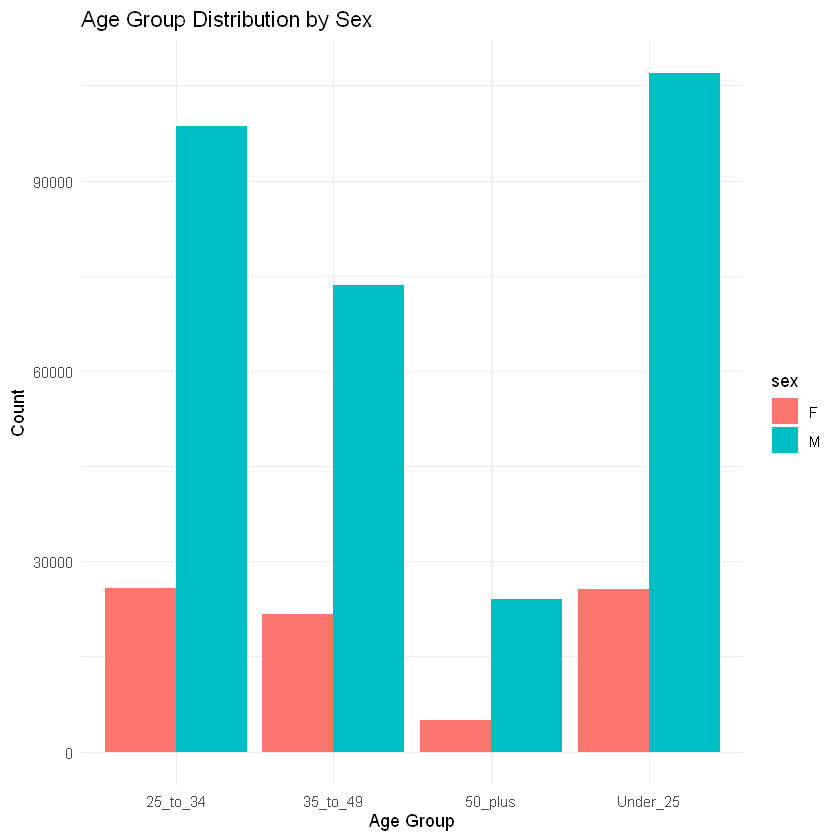

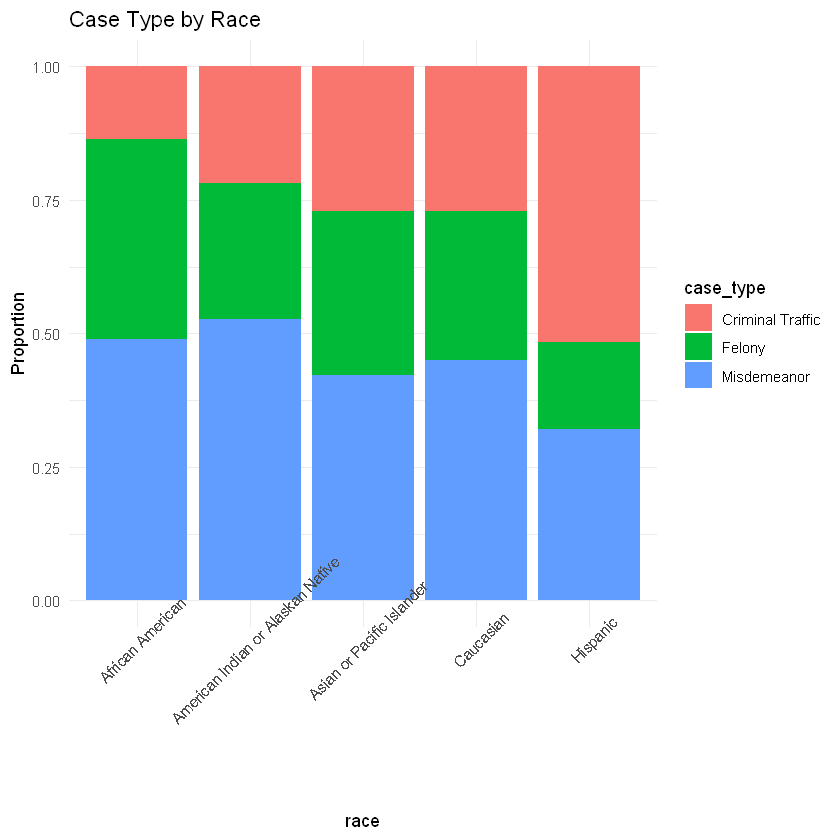

In [6]:
# Sex distribution
wis_eda %>%
  count(sex) %>%
  mutate(proportion = round(n / sum(n), 3)) %>%
  arrange(-proportion)

# Race distribution
wis_eda %>%
  count(race) %>%
  mutate(proportion = round(n / sum(n), 3)) %>%
  arrange(-proportion)

# Age group visualization
ggplot(wis_eda, aes(x = age_group, fill = sex)) +
  geom_bar(position = "dodge") +
  labs(title = "Age Group Distribution by Sex", y = "Count", x = "Age Group") +
  theme_minimal()

# Race vs. Case Type
ggplot(wis_eda, aes(x = race, fill = case_type)) +
  geom_bar(position = "fill") +
  labs(title = "Case Type by Race", y = "Proportion") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45))


- Males account for more offenses than Females as per this data in Wisonsin in the years 2008-2012.
- While Caucasian have the highest percentage of crimes committed, more serious crimes(Felony) have highest proportion among African Americans as compared to other groups.
- Overall, Age groups of under 25 have committed more offenses than other age groups.

In [7]:
#checking the education data to see if data from base data approximately matched data from USDA education data
edu_check <- wis_eda %>%
filter(FIPS == 55079) %>%
select(new_id ,year,FIPS,County_Name,pct_college,pct_somecollege,avg_pct_college,avg_pct_somecollege,'Percent.of.adults.completing.some.college.or.associate.degree','Percent.of.adults.with.a.bachelor.s.degree.or.higher',
      )
head(edu_check)


,new_id,year,FIPS,County_Name,pct_college,pct_somecollege,avg_pct_college,avg_pct_somecollege,Percent.of.adults.completing.some.college.or.associate.degree,Percent.of.adults.with.a.bachelor.s.degree.or.higher
,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3,2012,55079,Milwaukee,0.10051860,0.2089198,0.1965047,0.2803555,28.74796,27.67479
2,79,2012,55079,Milwaukee,0.06653797,0.2578507,0.1965047,0.2803555,28.74796,27.67479
3,136,2008,55079,Milwaukee,0.20622582,0.2908196,0.1965047,0.2803555,28.74796,27.67479
4,148,2011,55079,Milwaukee,0.18026789,0.2801699,0.1965047,0.2803555,28.74796,27.67479
5,195,2009,55079,Milwaukee,0.20946520,0.3048599,0.1965047,0.2803555,28.74796,27.67479
6,223,2009,55079,Milwaukee,0.21057327,0.3179350,0.1965047,0.2803555,28.74796,27.67479


- The differences observed from USDA Education data and base education data from Wisonsin dataset is because USDA contains 5 years ACS estimates.
- This is more precice than 1 year estimate.
- Another reason is due to the fact that the data is different across rows with same County and Year but different zip.(The zip is psuedo)
- When we observe the avg_pct_somecollege we see that it matches our USDA data as these are aggregated by counties and added to dataset.

### C. Case Counts and Types

case_type,n,proportion
<chr>,<int>,<dbl>
Criminal Traffic,99827,0.2618035
Felony,109894,0.2882050
Misdemeanor,171584,0.4499915


Warning message:
"Removed 167780 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


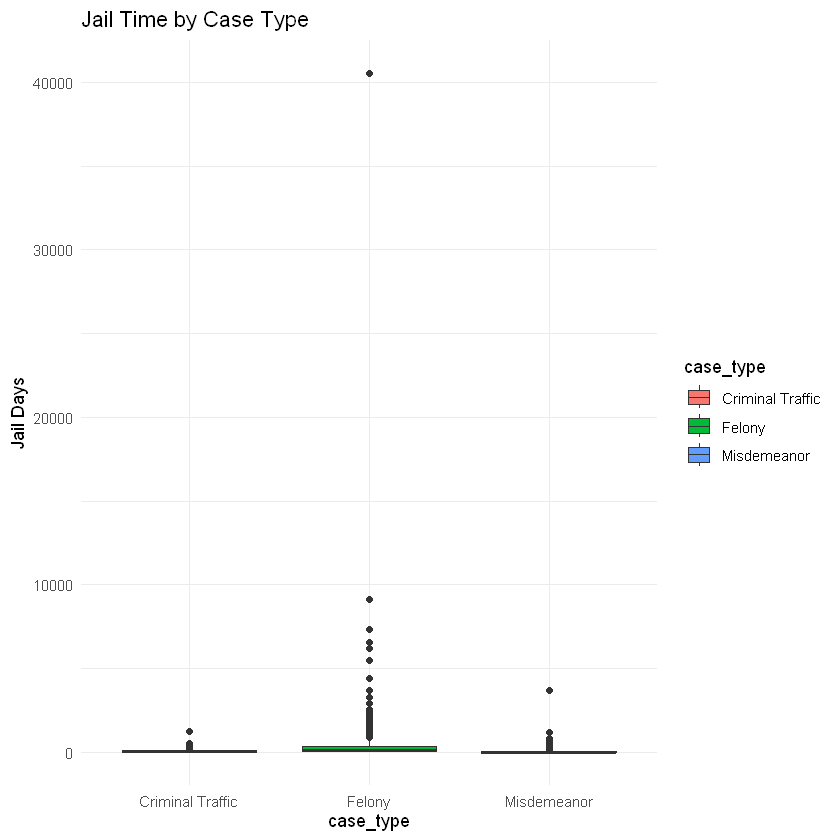

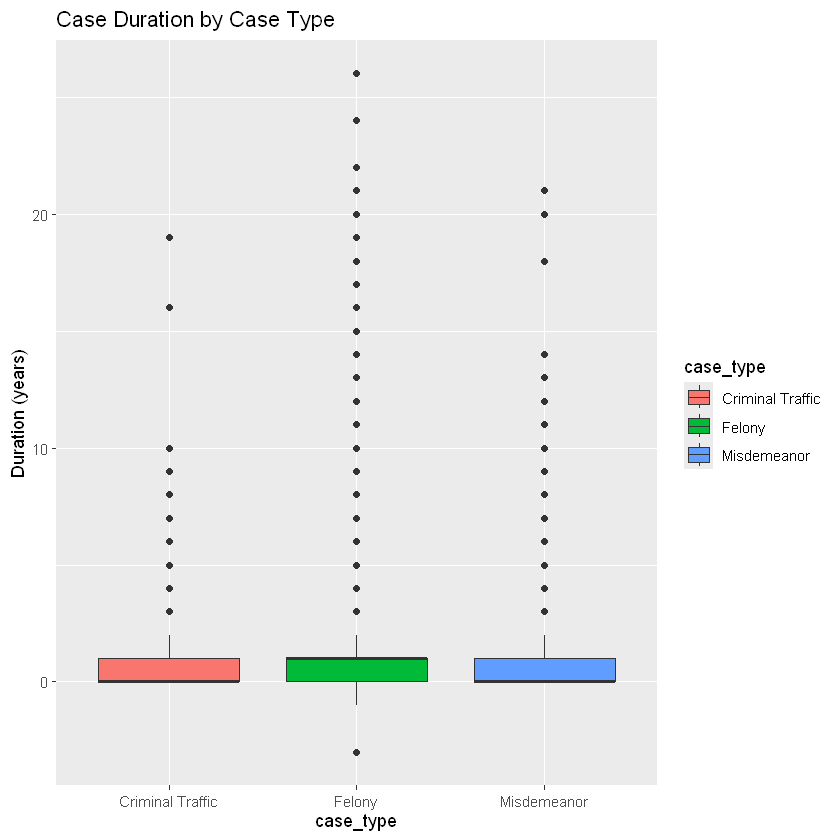

In [8]:
# Case type frequency
wis_eda %>%
  count(case_type) %>%
  mutate(proportion = n / sum(n))


# Jail time by Case Type
ggplot(wis_eda, aes(x = case_type, y = jail, fill = case_type)) +
  geom_boxplot() +
  labs(title = "Jail Time by Case Type", y = "Jail Days") +
  theme_minimal()

ggplot(wis_eda, aes(x = case_type, y = case_duration, fill = case_type)) +
  geom_boxplot() +
  labs(title = "Case Duration by Case Type", y = "Duration (years)")


- Most cases resolve within a year and very few cases take longer.
- A deeper look into this could provide some insight

In [9]:
# Cases that has taken longer than 10 years
wis_eda %>% 
filter(case_duration > 10) %>% 
select(case_type, age_offense, age_judge,case_duration, County_Name) %>%
group_by(case_type) %>%
summarise(
    n_cases = n()
    
  )

case_type,n_cases
<chr>,<int>
Criminal Traffic,2
Felony,77
Misdemeanor,13


- A lot of the cases that take longer are Felony

### D. Recidivism patterns

[1] 0.3919671

case_type,recid_rate
<chr>,<dbl>
Criminal Traffic,0.3735963
Felony,0.3597103
Misdemeanor,0.4233145


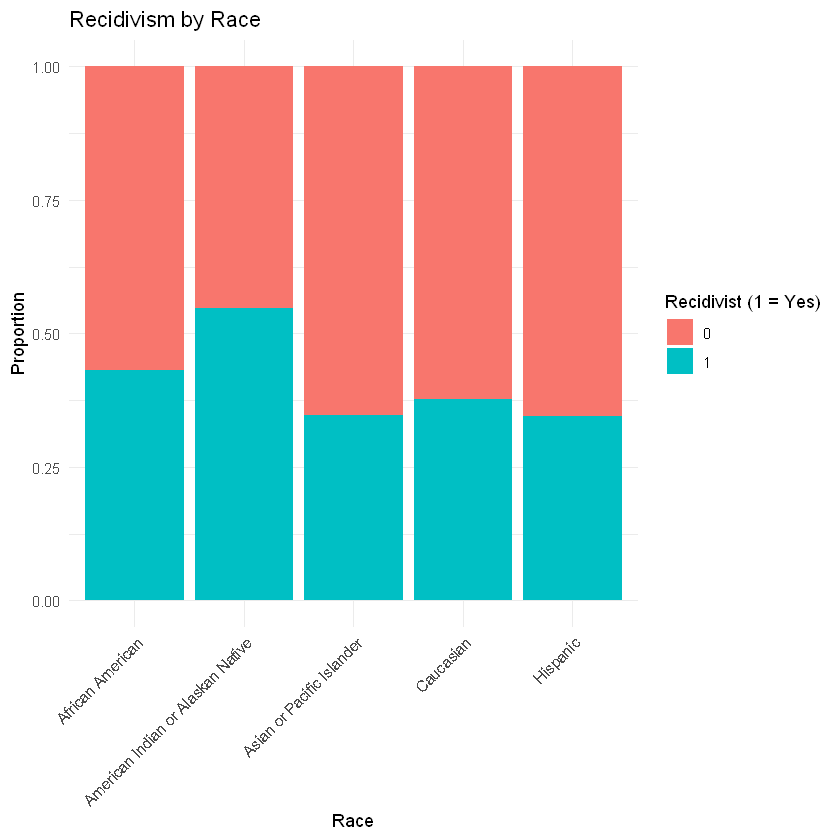

In [10]:
# Overall recidivism rate
mean(wis_eda$is_recid_new, na.rm = TRUE)

# Recidivism by case type
wis_eda %>%
  group_by(case_type) %>%
  summarise(recid_rate = mean(is_recid_new, na.rm = TRUE))


# Visualize recidivism by race
ggplot(wis_eda, aes(x = race, fill = factor(is_recid_new))) +
  geom_bar(position = "fill") +
  labs(
    title = "Recidivism by Race",
    x = "Race",
    y = "Proportion",
    fill = "Recidivist (1 = Yes)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


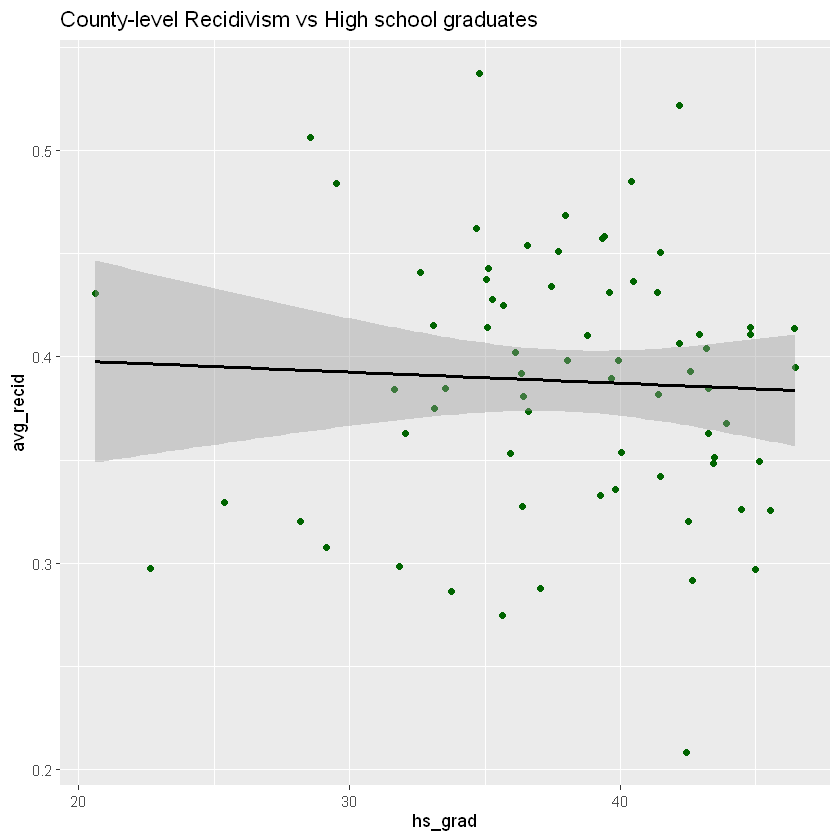

`geom_smooth()` using formula = 'y ~ x'


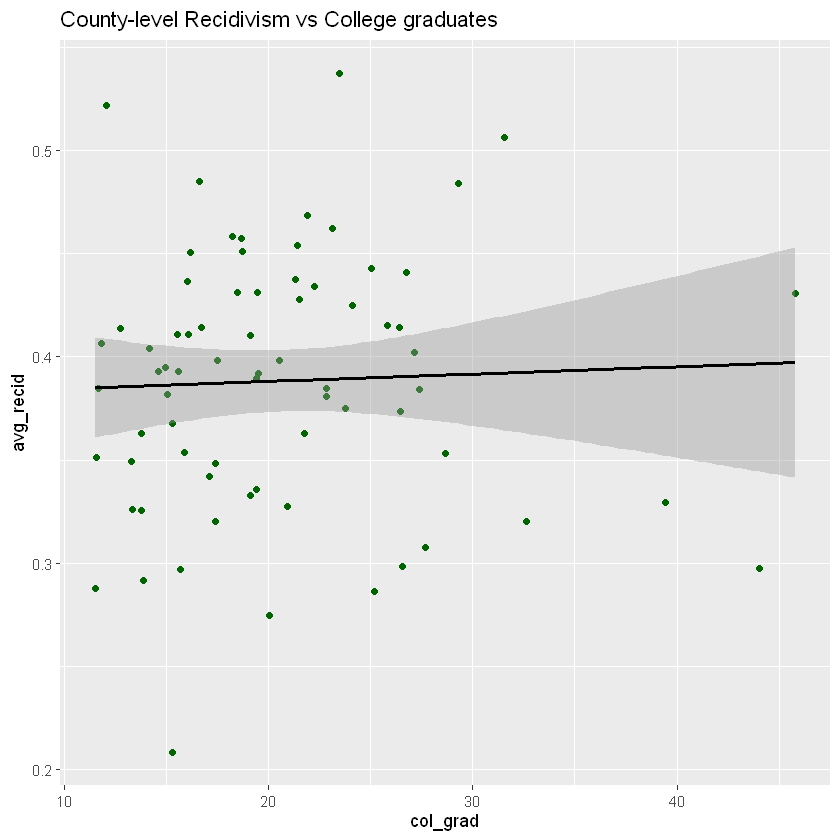

`geom_smooth()` using formula = 'y ~ x'


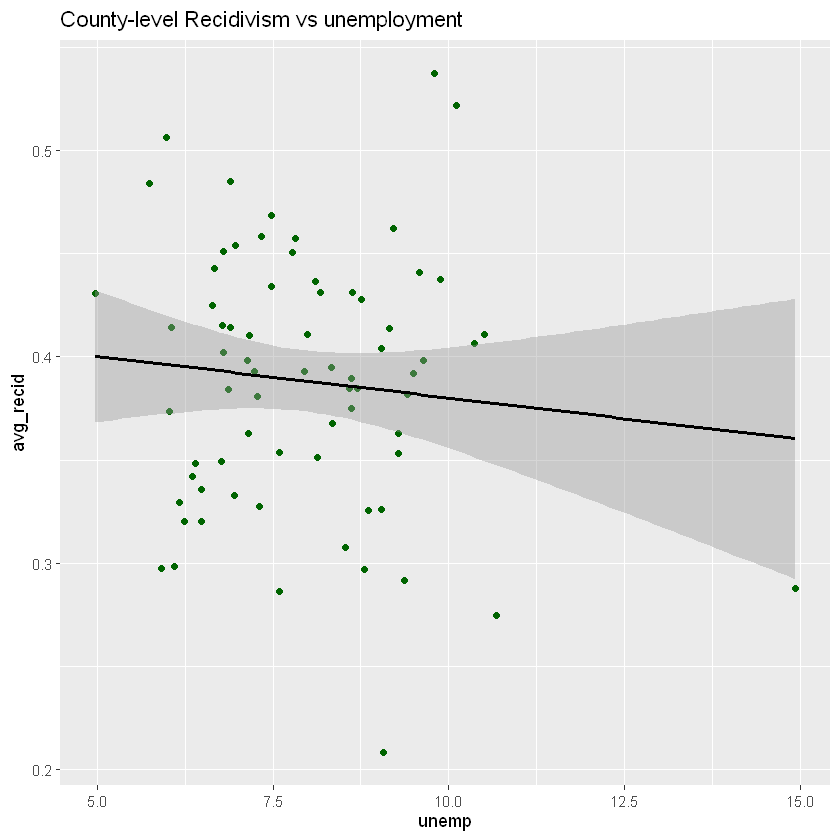

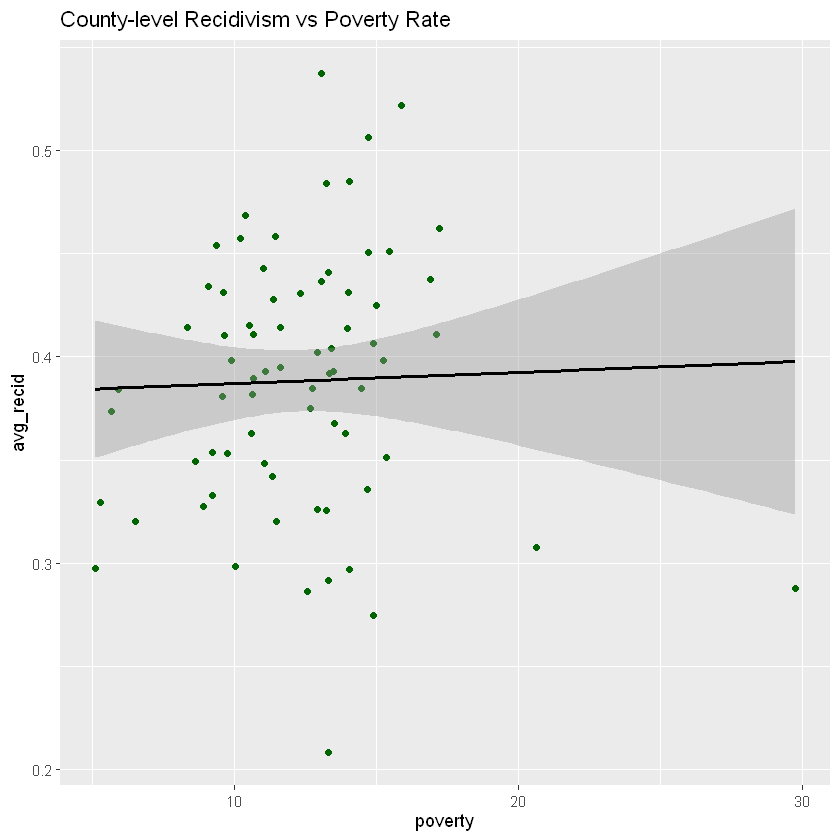

In [11]:
# Aggregate by county to visualize
agg_socio <- wis_eda %>%
  group_by(County_Name) %>%
  summarise(
    avg_recid = mean(is_recid_new, na.rm = TRUE),
    poverty = mean(SAEPOVRTALL_PT, na.rm = TRUE),
    unemp = mean(Unemployment_rate, na.rm = TRUE),
    hs_grad = mean(`Percent.of.adults.who.are.high.school.graduates..or.equivalent.`, na.rm = TRUE),
    col_grad = mean(`Percent.of.adults.with.a.bachelor.s.degree.or.higher`, na.rm = TRUE)
    #col_grad = mean(pct_college, na.rm = TRUE)
  )


# County level Recidivism vs high school graduates
ggplot(agg_socio, aes(x = hs_grad, y = avg_recid)) +
  geom_point(color = "darkgreen") +
  geom_smooth(method = "lm", color = "black") +
  labs(title = "County-level Recidivism vs High school graduates")

# County level Recidivism vs college graduates
ggplot(agg_socio, aes(x = col_grad, y = avg_recid)) +
  geom_point(color = "darkgreen") +
  geom_smooth(method = "lm", color = "black") +
  labs(title = "County-level Recidivism vs College graduates")

# County level Recidivism vs Unemplyment
ggplot(agg_socio, aes(x = unemp, y = avg_recid)) +
  geom_point(color = "darkgreen") +
  geom_smooth(method = "lm", color = "black") +
  labs(title = "County-level Recidivism vs unemployment")

# County level Recidivism vs Poverty
ggplot(agg_socio, aes(x = poverty, y = avg_recid)) +
  geom_point(color = "darkgreen") +
  geom_smooth(method = "lm", color = "black") +
  labs(title = "County-level Recidivism vs Poverty Rate")




- These plots show a weak relationship when we see the data on an average.
- Perhaps, a combination of socio economic factors might have a strong influence on recidivism.

In [12]:
# recidivism by age group and Prior offenses
wis_eda %>%
  group_by(age_group, has_priors) %>%
  summarise(
    n = n(),
    recid_rate = mean(is_recid_new, na.rm = TRUE)
  ) %>%
  arrange(desc(recid_rate))


`summarise()` has grouped output by 'age_group'. You can override using the
`.groups` argument.


age_group,has_priors,n,recid_rate
<chr>,<int>,<int>,<dbl>
Under_25,1,93155,0.5269497
25_to_34,1,100833,0.4438725
35_to_49,1,74539,0.3841613
Under_25,0,39346,0.3064352
50_plus,1,20183,0.3009463
25_to_34,0,23608,0.1959082
35_to_49,0,20747,0.1583361
50_plus,0,8894,0.1054644


Age group Under 25 with priors has the highest rate of recidivism. Even if there weren't any priors, Under_25 is on the list of highest recidivism.

In [13]:
# Top 10 counties by recidivism rate 
top10_counties <- wis_eda %>%
  group_by(County_Name) %>%
  summarise(avg_recid = mean(is_recid_new, na.rm = TRUE), .groups = "drop_last") %>%
  slice_max(order_by = avg_recid, n = 10) %>% #Get top 10
  arrange(-avg_recid)
top10_counties

County_Name,avg_recid
<chr>,<dbl>
Vilas,0.5371339
Forest,0.5220228
Eau Claire,0.5065789
Monroe,0.4852151
La Crosse,0.4840286
Marathon,0.4683328
Ashland,0.4623362
Chippewa,0.4581306
Wood,0.4574955


- Vilas , Forest and Eau Claire Counties have the highest recidivism rates with rates above 50%.

case_type,County_Name,avg_recid
<chr>,<chr>,<dbl>
Criminal Traffic,Eau Claire,0.4663632
Criminal Traffic,Ashland,0.4617834
Criminal Traffic,Wood,0.4569450
Felony,Forest,0.4950298
Felony,Eau Claire,0.4950052
Felony,Monroe,0.4940618
Misdemeanor,Vilas,0.6403823
Misdemeanor,Forest,0.5408022
Misdemeanor,Eau Claire,0.5299092


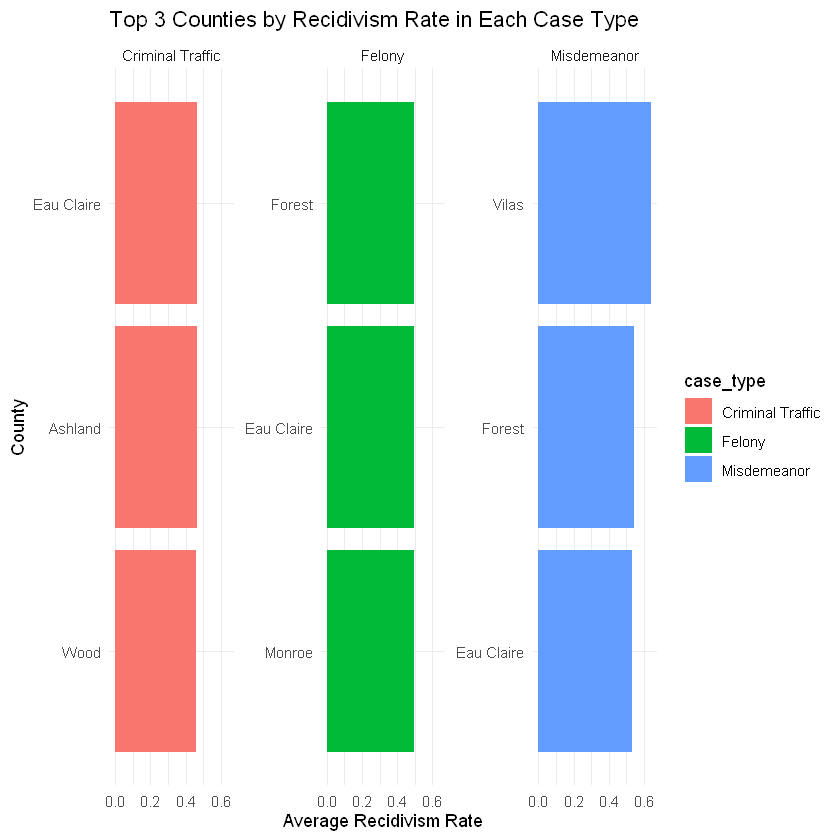

In [14]:
# Recidivism by Case type and County

# Top 3 counties by recidivism rate within each case type
top3_per_case <- wis_eda %>%
  group_by(case_type, County_Name) %>%
  summarise(avg_recid = mean(is_recid_new, na.rm = TRUE), .groups = "drop_last") %>%
  slice_max(order_by = avg_recid, n = 3) %>%
  arrange(case_type, -avg_recid)

top3_per_case
# Plot
ggplot(top3_per_case, aes(x = reorder(County_Name, avg_recid), 
                          y = avg_recid, fill = case_type)) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_wrap(~ case_type, scales = "free_y") +
  coord_flip() +
  labs(title = "Top 3 Counties by Recidivism Rate in Each Case Type",
       x = "County", y = "Average Recidivism Rate") +
  theme_minimal()



- The top 3 counties with highest recidivism rate in each category if case_type is in the above table.
- Eau Claire is one county that has a high recidivism rate across all kinds of offenses.

### E. Education, Poverty and Unemployment. How are they correlated?

In [15]:
# Select education-related columns
edu_unique <- wis_eda %>%
  select(
    County_Name,
    `Percent.of.adults.who.are.not.high.school.graduates`,
    `Percent.of.adults.who.are.high.school.graduates..or.equivalent.`,
    `Percent.of.adults.completing.some.college.or.associate.degree`,
    `Percent.of.adults.with.a.bachelor.s.degree.or.higher`
  ) %>%
  distinct()

# Number of unique rows (counties)
nrow(edu_unique)

# Optional: View first few unique combinations
head(edu_unique)


[1] 72

,County_Name,Percent.of.adults.who.are.not.high.school.graduates,Percent.of.adults.who.are.high.school.graduates..or.equivalent.,Percent.of.adults.completing.some.college.or.associate.degree,Percent.of.adults.with.a.bachelor.s.degree.or.higher
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Milwaukee,14.45220,29.12505,28.74796,27.67479
2,Dane,5.28706,20.62301,28.27031,45.81962
3,Ozaukee,4.04256,22.63666,29.29806,44.02273
4,Marathon,10.75160,37.96927,29.36335,21.91578
5,Walworth,10.25938,33.74080,30.80976,25.19006
6,Burnett,10.62628,39.91273,31.99008,17.47091


In [16]:
# Select education-related columns
edu_unique_pct <- wis_eda %>%
  select(
    County_Name,
    avg_year_pct_college,
    avg_year_pct_somecollege
  ) %>%
  distinct()

# Number of unique rows (counties)
nrow(edu_unique_pct)

# Optional: View first few unique combinations
head(edu_unique_pct)

[1] 360

,County_Name,avg_year_pct_college,avg_year_pct_somecollege
,<chr>,<dbl>,<dbl>
1,Milwaukee,0.1986142,0.2818900
2,Dane,0.4018373,0.2831047
3,Ozaukee,0.2854197,0.2985585
4,Marathon,0.2152944,0.2980946
5,Marathon,0.2147736,0.2994315
6,Walworth,0.2465078,0.2970075


In [17]:
# Select county-year socioeconomic variables
socio_unique <- wis_eda %>%
  select(
    County_Name, year,
    SAEPOVRTALL_PT, Unemployment_rate
  ) %>%
  distinct()

# Count unique combinations
nrow(socio_unique)

# Check example rows
head(socio_unique)


[1] 360

,County_Name,year,SAEPOVRTALL_PT,Unemployment_rate
,<chr>,<int>,<dbl>,<dbl>
1,Milwaukee,2012,22.5,8.5
2,Dane,2009,13.1,6.0
3,Ozaukee,2008,4.2,3.9
4,Marathon,2008,7.9,4.6
5,Marathon,2010,11.9,9.1
6,Walworth,2012,13.5,7.1


- My analysis on Education data is all County level, since I have used 5 year estimates. Hence, there are 72 unique values for all my education data as there are 72 counties
- Using the year and conty aggregated base education data available in the Wisconsin dataset gives a unique 360 values.
- Poverty and unemployment data are all year-wise and county level data. The analysis is restricted to years 2008-2012. So, the unique data is about 72*5 = 360

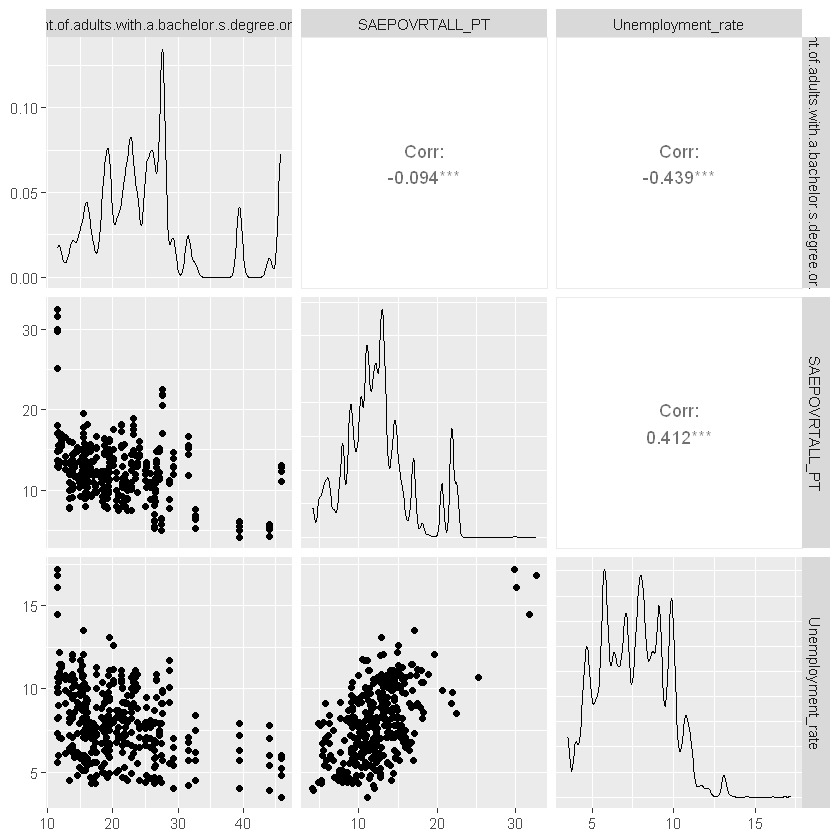

In [18]:
# Education vs Poverty vs Unemployment. How are they interlinked?
wis_eda %>%
  select(Percent.of.adults.with.a.bachelor.s.degree.or.higher,
         SAEPOVRTALL_PT,
         Unemployment_rate) %>%
  ggpairs()



- Bachelor’s degree vs. Poverty rate :Corr = -0.094
A very weak negative correlation — areas with slightly higher education levels tend to have slightly lower poverty, but the relationship is minimal.

- Bachelor’s degree vs. Unemployment rate → Corr = -0.439
A moderate negative correlation — higher education levels are associated with lower unemployment. 

- Poverty rate vs. Unemployment rate → Corr = 0.412
A moderate positive correlation — higher unemployment is linked with higher poverty rates, which makes sense socioeconomically.

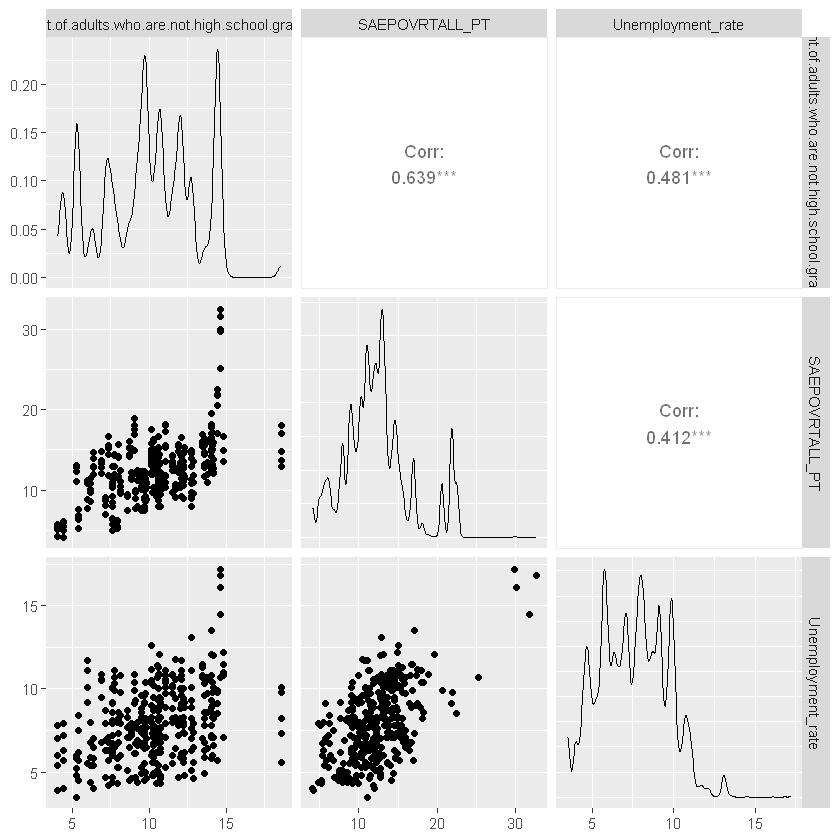

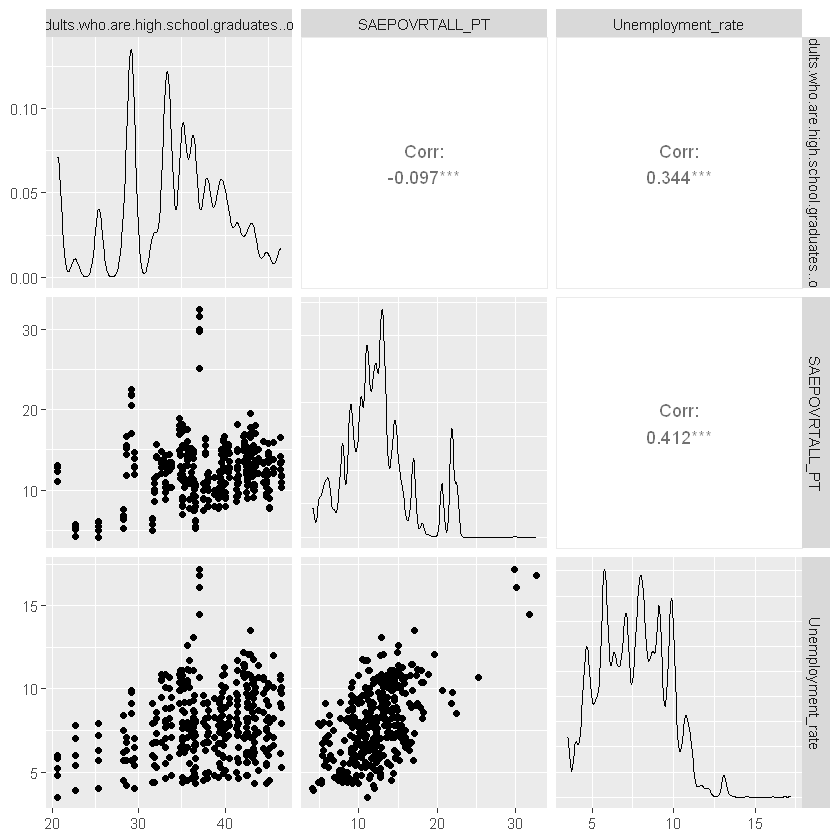

In [19]:
# Checking other education like high school education and some college degree

wis_eda %>%
  select(Percent.of.adults.who.are.not.high.school.graduates  ,
         SAEPOVRTALL_PT,
         Unemployment_rate) %>%
  ggpairs()

wis_eda %>%
  select(Percent.of.adults.who.are.high.school.graduates..or.equivalent. ,
         SAEPOVRTALL_PT,
         Unemployment_rate) %>%
  ggpairs()

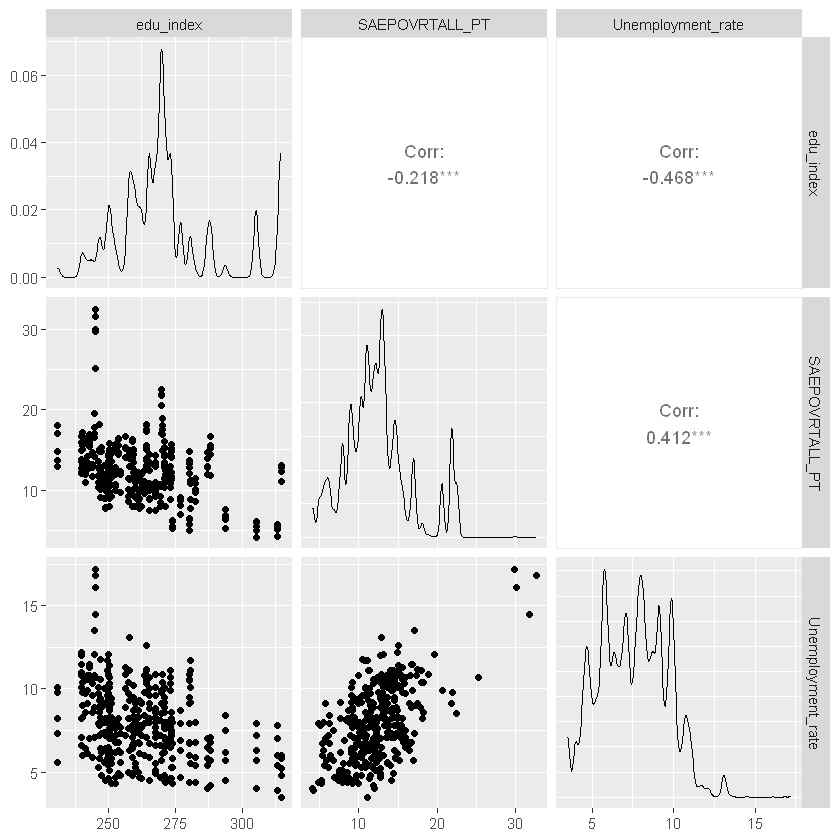

In [20]:
wis_eda %>%
  select(edu_index ,
         SAEPOVRTALL_PT,
         Unemployment_rate) %>%
  ggpairs()

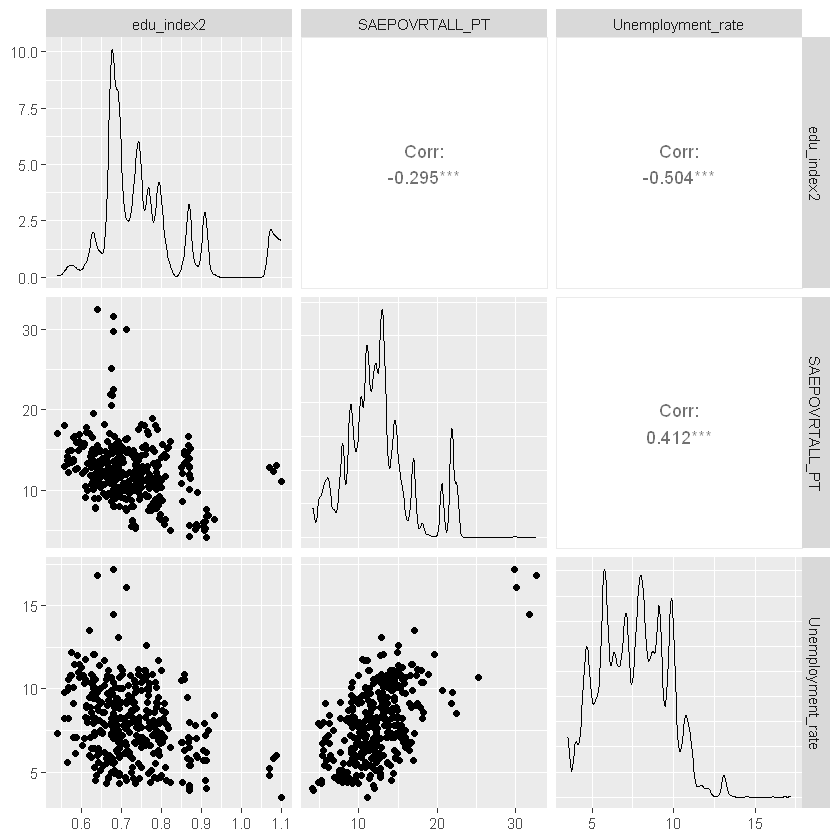

In [21]:
wis_eda %>%
  select(edu_index2 ,
         SAEPOVRTALL_PT,
         Unemployment_rate) %>%
  ggpairs()

- These plots confirm the same as well. More the Percentage of 'not' highschool graduate, more the unemployment rate.
- Poverty and unemployment also have a  positive correlation - 0.412
- There is a decent correlation between education, poverty and Unemployment data when education index(a weighted index that combines the 4 education related data) is used.
- A slightly higher correlation between the education index created from base edication data and poverty and unemployment is observed.

### F. Recidivism change over the years 2008-2012

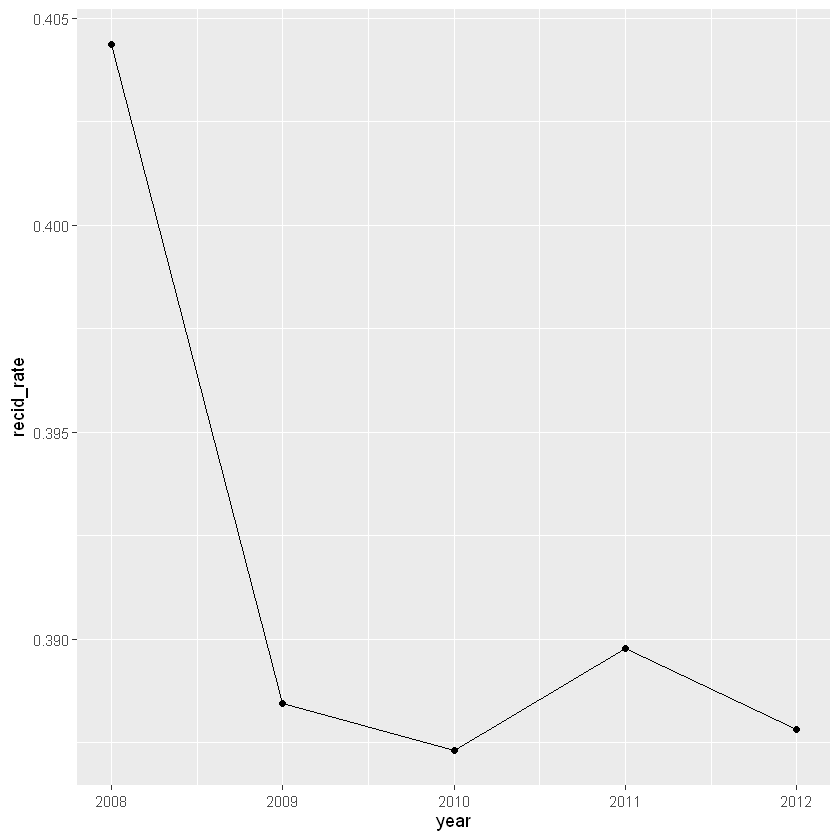

In [22]:
wis_eda %>%
  group_by(year) %>%
  summarise(recid_rate = mean(is_recid_new, na.rm = TRUE)) %>%
  ggplot(aes(x = year, y = recid_rate)) +
  geom_line() + geom_point()


- We observe a lot of recidivism cases in the year 2008 and there is a sudden drop and remains low except for a momentary spike in  the year 2011.

year,avg_recid,avg_poverty,avg_unemp,avg_edu
<int>,<dbl>,<dbl>,<dbl>,<dbl>
2008,0.4043667,10.36621,5.014637,0.7663323
2009,0.3884511,12.20935,9.106204,0.7654867
2010,0.3873090,13.26669,8.715012,0.7584857
2011,0.3897768,13.12825,7.776607,0.7559069
2012,0.3878115,13.12853,7.137886,0.7552573


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


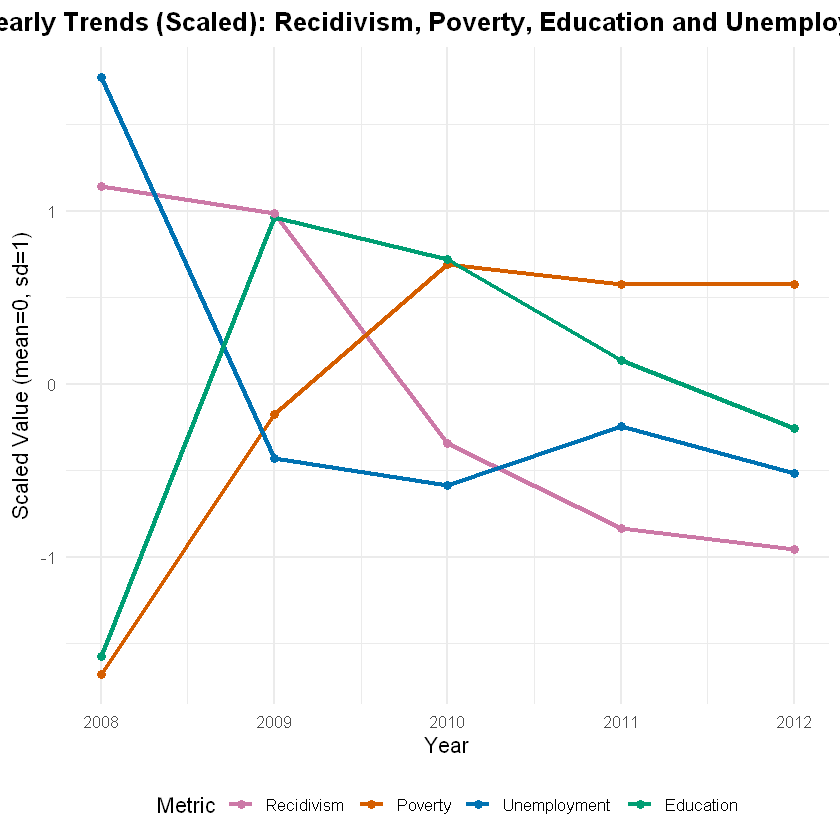

In [23]:
# Compute yearly summary by county
year_summary <- wis_eda %>%
  group_by(year) %>%
  summarise(
    avg_recid = mean(is_recid_new, na.rm = TRUE),
    avg_poverty = mean(SAEPOVRTALL_PT, na.rm = TRUE),
    avg_unemp = mean(Unemployment_rate, na.rm = TRUE),
    avg_edu = mean(edu_index2, na.rm = TRUE),
    .groups = "drop"
  )

# View a few rows
View(year_summary)


# Scale all metrics to mean=0, sd=1 for a clean comparison
year_summary_scaled <- year_summary %>%
  mutate(
    recid_scaled = scale(avg_recid),
    poverty_scaled = scale(avg_poverty),
    unemp_scaled = scale(avg_unemp),
    edu_scaled = scale(avg_edu)
  ) %>%
  select(year, recid_scaled, poverty_scaled, unemp_scaled,edu_scaled) %>%
  pivot_longer(-year, names_to = "Metric", values_to = "Value")

# Plot scaled metrics
ggplot(year_summary_scaled, aes(x = year, y = Value, color = Metric)) +
  geom_line(size = 1.2) +
  geom_point(size = 2) +
  scale_color_manual(
    values = c("recid_scaled" = "#0072B2", 
               "poverty_scaled" = "#D55E00", 
               "unemp_scaled" = "#009E73",
               "edu_scaled" = "#CC79A7"),
    labels = c("Recidivism", "Poverty", "Unemployment","Education")
  ) +
  labs(
    title = "Yearly Trends (Scaled): Recidivism, Poverty, Education and Unemployment",
    x = "Year",
    y = "Scaled Value (mean=0, sd=1)",
    color = "Metric"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold", hjust = 0.5)
  )



- Poverty and Education over the years has a general upward trend.
- Recidivism and Unemployment has a declining trend between te years 2008-2012

### G. Distributions - Univariate Analysis

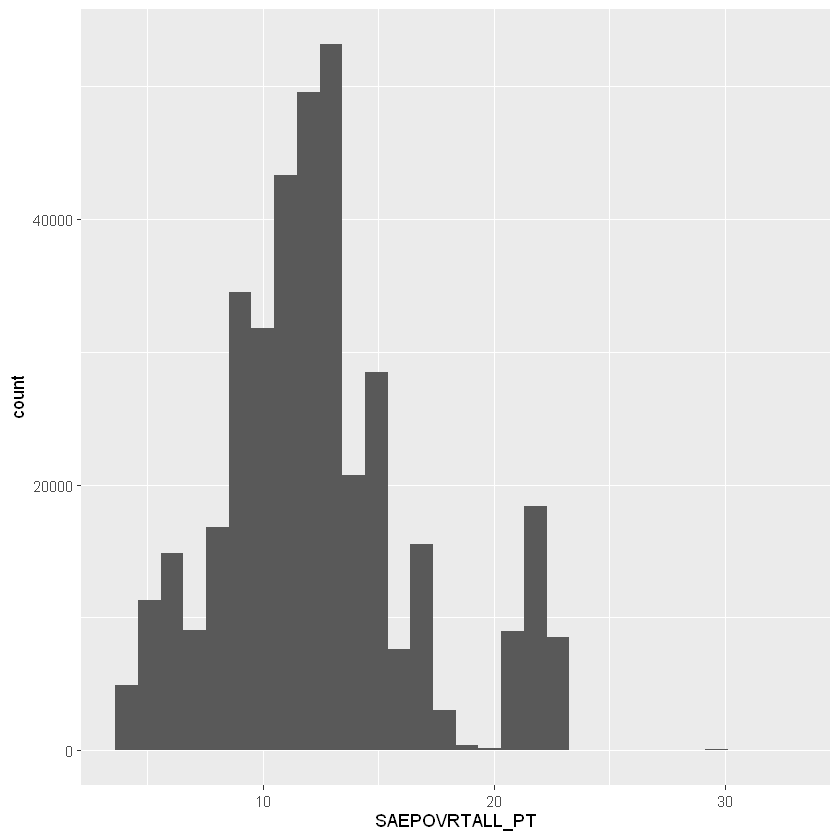

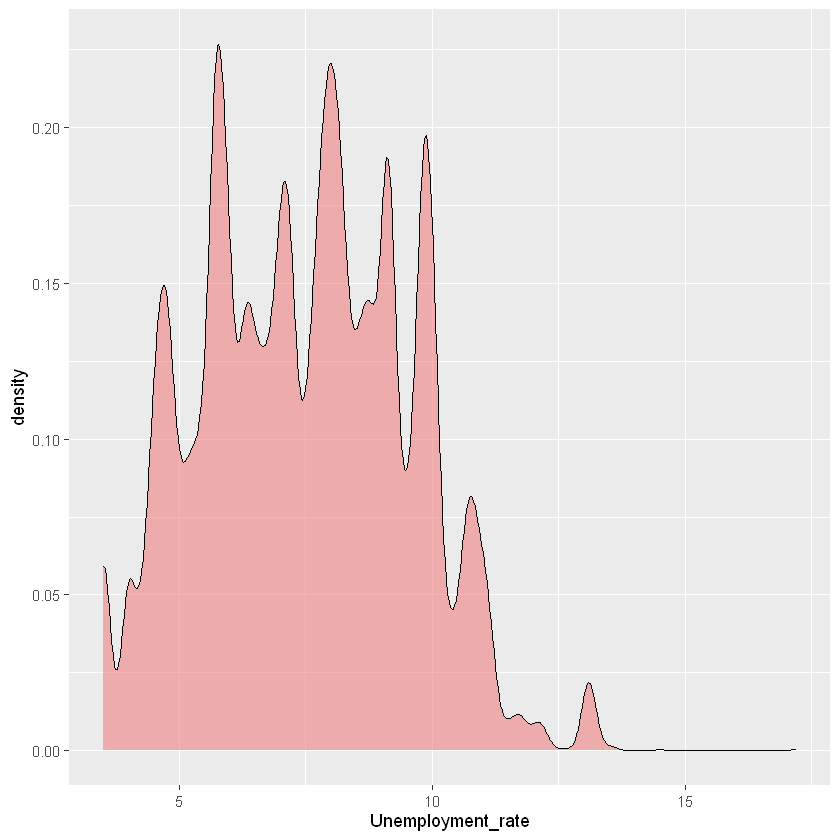

In [24]:
ggplot(wis_eda, aes(x = SAEPOVRTALL_PT)) + geom_histogram(bins = 30)
ggplot(wis_eda, aes(x = Unemployment_rate)) + geom_density(fill = "lightcoral", alpha = 0.6)


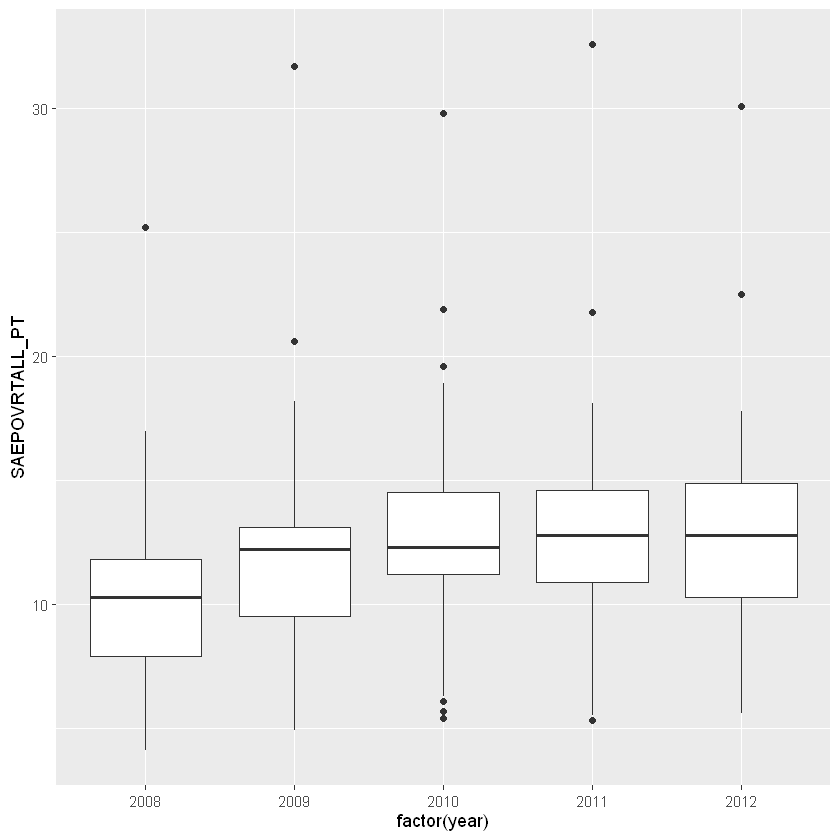

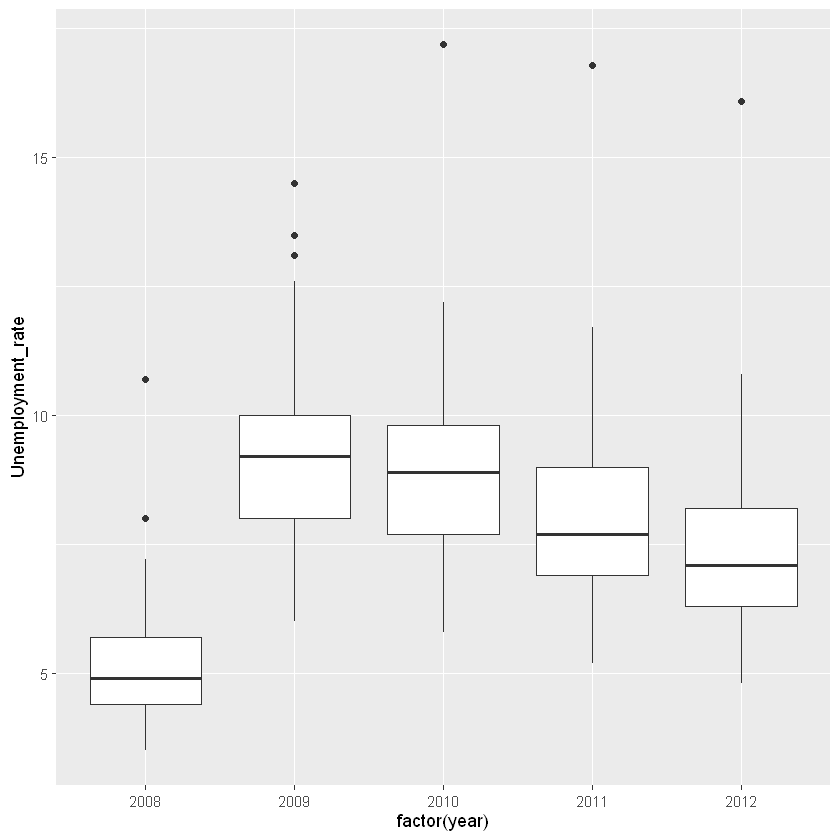

In [25]:
ggplot(wis_eda, aes(x = factor(year), y = SAEPOVRTALL_PT)) + geom_boxplot()
ggplot(wis_eda, aes(x = factor(year), y = Unemployment_rate)) + geom_boxplot()


- The distribution of Poverty looks slightly skewed, but suitable to use in regression.
- The distribution of unemployment rate looks noisy, adding a year interaction term might help with modelling.
- Checking the boxplots of Poverty and Unemployment over the years, the unemployment data has elevated levels in the years 2009 and 2010(Could possibly due to 2008 recession).

### H. Correlations

In [37]:
# Correlation Matrix for all numerical columns
# Select only numeric columns
numeric_data <- wis_eda %>%
  select(where(is.numeric), -county, -judge_id, -FIPS, -new_id,-zip,
    # Drop redundant socioeconomic variables
    -pct_urban, -pct_rural,  # they sum to 1
    -Civilian_labor_force, -Employed, -Unemployed,  # strongly correlated with Unemployment_rate
    
    # Drop other variables that are not needed
    -max_hist_jail, -min_hist_jail, -avg_hist_jail, -median_hist_jail,  
    -total_prior_severity,  # already correlated with total_priors
    -SAEPOVALL_PT  # raw count, while SAEPOVRTALL_PT is rate-based
     )
# Compute correlation matrix (use complete observations to avoid NA issues)
cor_matrix <- cor(numeric_data, use = "complete.obs")
cor_matrix

# Correlation with recidivism
recid_corr <- cor(numeric_data, wis_eda$is_recid_new, use = "complete.obs")
sort(recid_corr[,1], decreasing = TRUE)

,age_offense,age_judge,highest_severity,release,probation,is_recid_new,recid_180d,pct_black,pct_hisp,pct_male,⋯,total_priors,has_priors,has_jail_history,case_duration,edu_index,avg_pct_college,avg_pct_somecollege,avg_year_pct_college,avg_year_pct_somecollege,edu_index2
age_offense,1.0000000000,0.9975002522,-0.11168782,-0.081662169,-0.090891593,-0.137407462,-0.137845207,-0.030606128,-0.007449392,0.0106338830,⋯,0.080537764,-0.007085719,0.068359326,-7.327341e-03,0.019399208,0.024186962,1.744100e-03,0.023980125,0.002241586,0.024269433
age_judge,0.9975002522,1.0000000000,-0.10991404,-0.081943076,-0.092182625,-0.141313306,-0.141732724,-0.028371054,-0.005938547,0.0106020491,⋯,0.081641478,-0.006542703,0.069457539,6.335199e-02,0.019286614,0.023412957,9.128199e-04,0.023188436,0.001425878,0.023363219
highest_severity,-0.1116878244,-0.1099140398,1.00000000,0.234442521,0.227344505,0.089061601,0.088774498,0.174740042,0.044569381,-0.0097643297,⋯,0.149777270,0.137254514,0.185077542,2.196884e-02,-0.031029341,-0.055652974,-7.300070e-02,-0.056067071,-0.072542088,-0.066268726
release,-0.0816621687,-0.0819430756,0.23444252,1.000000000,0.823916079,-0.060616230,-0.049907068,0.286741840,0.087695879,-0.1276743968,⋯,-0.072897008,-0.007546768,-0.054154252,-6.265612e-03,-0.082736949,-0.178925215,-2.050157e-01,-0.179158067,-0.205834096,-0.208081299
probation,-0.0908915927,-0.0921826246,0.22734450,0.823916079,1.000000000,-0.026011547,-0.017436328,0.022178950,-0.003740917,-0.0130320041,⋯,-0.055783694,-0.009346856,-0.102108066,-2.081907e-02,-0.060759713,-0.078542025,6.040108e-03,-0.078360510,0.006878424,-0.077295674
is_recid_new,-0.1374074618,-0.1413133063,0.08906160,-0.060616230,-0.026011547,1.000000000,0.986455228,-0.055780253,-0.038411266,0.0536418994,⋯,0.265583067,0.207824430,0.130752857,-5.912676e-02,0.001934374,0.025468020,5.977215e-02,0.025657202,0.059473881,0.034044733
recid_180d,-0.1378452070,-0.1417327244,0.08877450,-0.049907068,-0.017436328,0.986455228,1.000000000,-0.051975823,-0.037278478,0.0515432084,⋯,0.261030583,0.204039666,0.126979512,-5.887968e-02,0.001105777,0.023436456,5.781724e-02,0.023623096,0.057497297,0.031733248
pct_black,-0.0306061277,-0.0283710540,0.17474004,0.286741840,0.022178950,-0.055780253,-0.051975823,1.000000000,0.025629530,-0.3574990334,⋯,-0.043579121,-0.014867612,0.086654915,3.077081e-02,0.024657220,-0.115127617,-3.929503e-01,-0.115322989,-0.391254379,-0.170563439
pct_hisp,-0.0074493925,-0.0059385473,0.04456938,0.087695879,-0.003740917,-0.038411266,-0.037278478,0.025629530,1.000000000,0.0551927866,⋯,-0.037550737,-0.025296191,0.014099375,2.117151e-02,0.044939167,-0.014294109,-2.472891e-01,-0.014503561,-0.247241134,-0.049479085
pct_male,0.0106338830,0.0106020491,-0.00976433,-0.127674397,-0.013032004,0.053641899,0.051543208,-0.357499033,0.055192787,1.0000000000,⋯,0.067446381,0.037010581,0.027083091,-1.522395e-04,-0.035447898,0.054621946,1.217256e-01,0.054366566,0.120250052,0.071322386


is_recid_new 
                                                    1.000000000 
                                                     recid_180d 
                                                    0.986455228 
                                             recid_180d_violent 
                                                    0.359245824 
                                                   total_priors 
                                                    0.265583067 
                                                     has_priors 
                                                    0.207824430 
                                               has_jail_history 
                                                    0.130752857 
                                               highest_severity 
                                                    0.089061601 
                                                           jail 
                                                    0.082826946 
                                            avg_pct_somecollege 
                                                    0.059772148 
                                       avg_year_pct_somecollege 
                                                    0.059473881 
                               X2013.Rural.urban.Continuum.Code 
                                                    0.056833112 
                                                       pct_male 
                                                    0.053641899 
  Percent.of.adults.completing.some.college.or.associate.degree 
                                                    0.049949865 
                                     X2013.Urban.Influence.Code 
                                                    0.046629694 
                                                     edu_index2 
                                                    0.034044733 
Percent.of.adults.who.are.high.school.graduates..or.equivalent. 
                                                    0.032313459 
                                           avg_year_pct_college 
                                                    0.025657202 
                                                avg_pct_college 
                                                    0.025468020 
                                                pct_somecollege 
                                                    0.021781361 
                                                  violent_crime 
                                                    0.002180396 
                                                      edu_index 
                                                    0.001934374 
                                                    pct_college 
                                                   -0.002105853 
                                                           year 
                                                   -0.005704298 
           Percent.of.adults.with.a.bachelor.s.degree.or.higher 
                                                   -0.014437719 
                                                      med_hhinc 
                                                   -0.021735851 
                                                pct_food_stamps 
                                                   -0.024836757 
                                                      probation 
                                                   -0.026011547 
                                              Unemployment_rate 
                                                   -0.027855928 
                                                       pct_hisp 
                                                   -0.038411266 
                                                       pop_dens 
                                                   -0.053945242 
                                                      pct_black 
                                                   -0.055780253 
            Percent.o

In [38]:
cor_pairs <- as.data.frame(as.table(cor_matrix))

#Filter for high correlations (≥ 0.5 or ≤ -0.5) but not self-correlations
high_cor <- cor_pairs %>%
  filter(Var1 != Var2, abs(Freq) >= 0.5) %>%
  arrange(desc(abs(Freq)))

# View top correlated pairs
head(high_cor,15)


,Var1,Var2,Freq
,<fct>,<fct>,<dbl>
1,avg_year_pct_college,avg_pct_college,0.9986903
2,avg_pct_college,avg_year_pct_college,0.9986903
3,age_judge,age_offense,0.9975003
4,age_offense,age_judge,0.9975003
5,avg_year_pct_somecollege,avg_pct_somecollege,0.9963003
6,avg_pct_somecollege,avg_year_pct_somecollege,0.9963003
7,edu_index2,avg_year_pct_college,0.9899734
8,avg_year_pct_college,edu_index2,0.9899734
9,edu_index2,avg_pct_college,0.9886141


Warning message in ind1:ind2:
"numerical expression has 2 elements: only the first used"


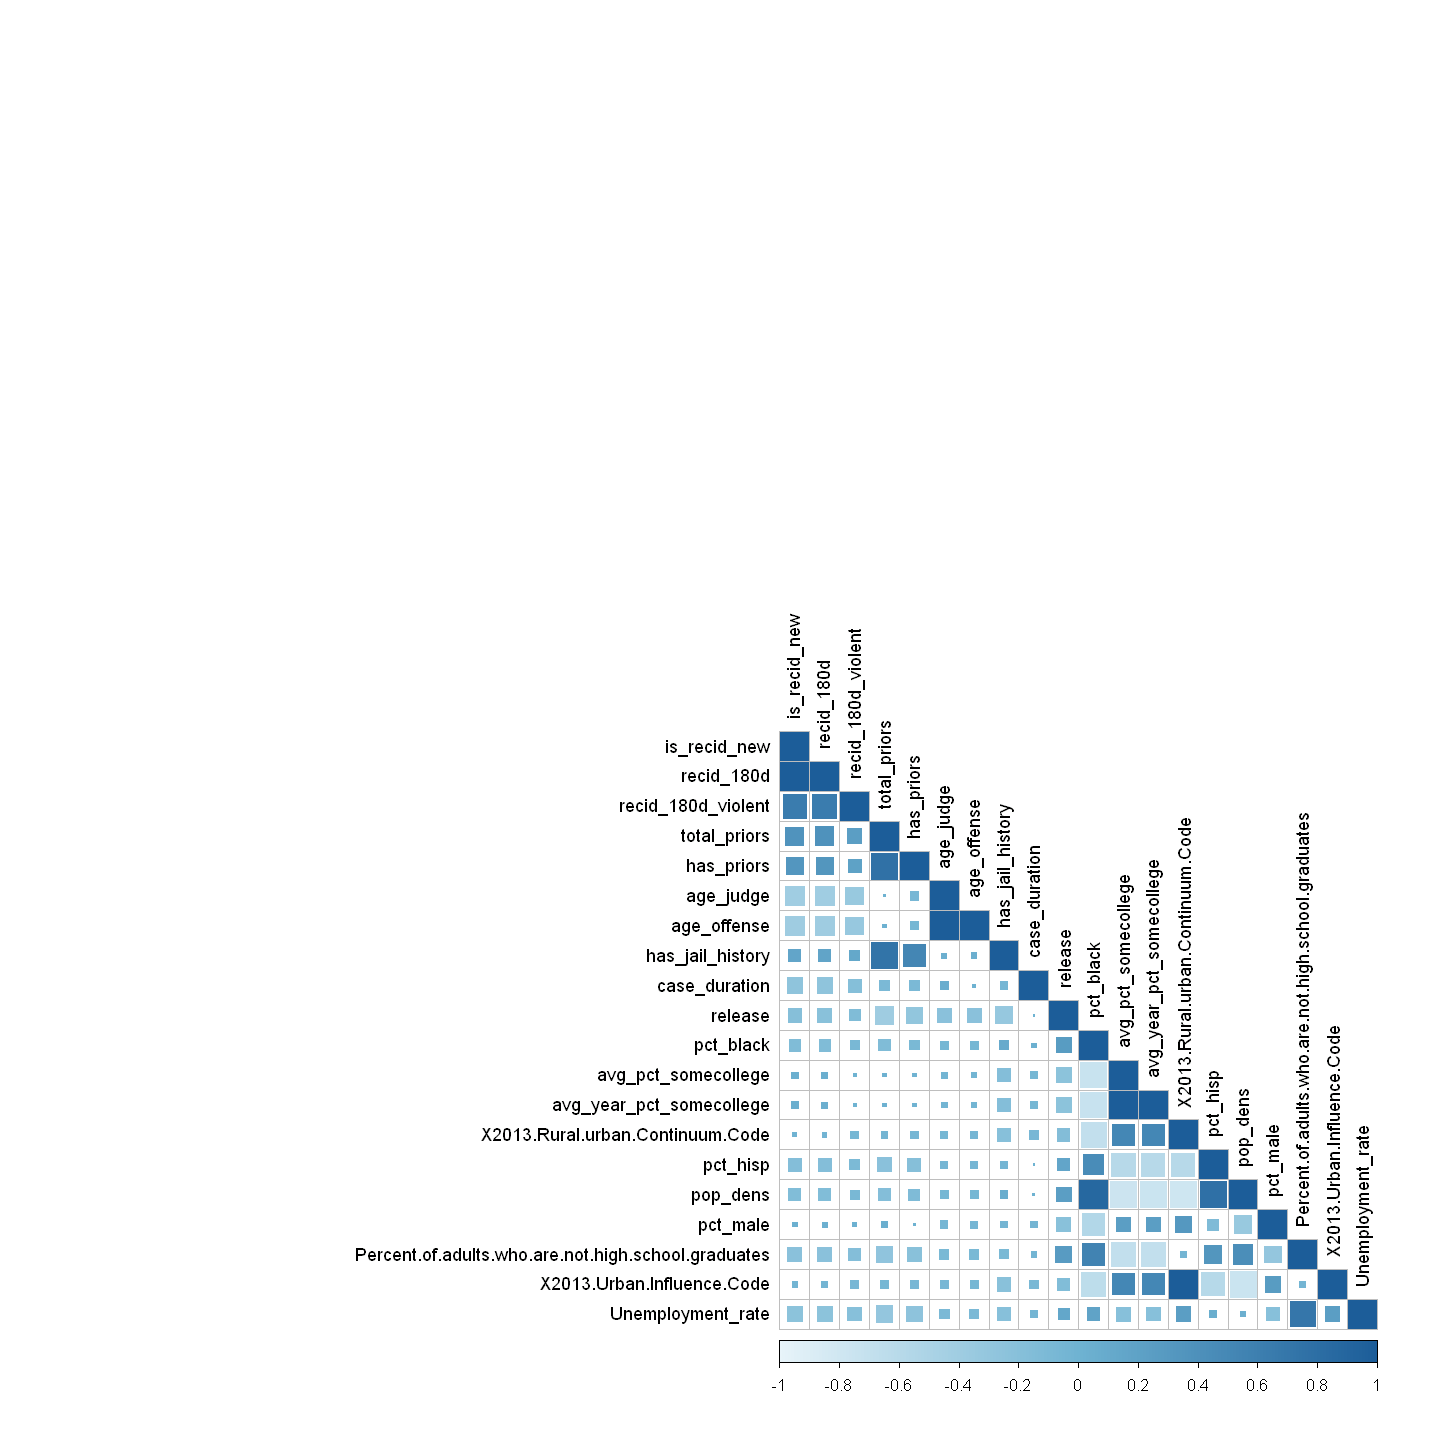

In [41]:
# keep only the top 20 most correlated variables
vars_to_keep <- names(sort(abs(cor(numeric_data, use = "pairwise.complete.obs")["is_recid_new", ]),
                           decreasing = TRUE))[1:20]

cor_sub <- cor(numeric_data[, vars_to_keep], use = "pairwise.complete.obs")

#corrplot::corrplot(cor_sub, method = "color", type = "upper", tl.cex = 0.9)

options(repr.plot.width = 12, repr.plot.height = 12)   # increase as needed

# png("corrplot.png",
#     width = 3000,     
#     height = 3000,    
#     res = 400)   

# corrplot(
#     cor(cor_sub),
#     method = 'square',
#     type = 'lower',
#     tl.col = 'black',
#     tl.cex = 0.9,
#     col = colorRampPalette(c("purple", "dark green"))(200)
# )

# dev.off()

corrplot(
  cor(cor_sub),
  method = 'square',
  type = 'lower',
  tl.col = 'black',
  tl.cex = 0.9,
  col = colorRampPalette(c("#e8f4fa", "#6fb3d2", "#1c5d99"))(200)
)

In [29]:
# Sort correlations by absolute value, but retain the sign
recid_corr_sorted <- recid_corr[order(abs(recid_corr[, 1]), decreasing = TRUE), , drop = FALSE]

# View sorted correlations with their signs
recid_corr_sorted


is_recid_new,1.000000000
recid_180d,0.986455228
recid_180d_violent,0.359245824
total_priors,0.265583067
has_priors,0.207824430
age_judge,-0.141313306
age_offense,-0.137407462
has_jail_history,0.130752857
highest_severity,0.089061601
jail,0.082826946
SAEPOVRTALL_PT,-0.061799459


- We observe moderate correlations between recidivism and priors and weak correlations with the socio economic variables.

### G. Summary of EDA

- Dataset has 381305 obs. of  57 variables.
- Males account for more offenses than Females as per this data in Wisonsin in the years 2008-2012.
- While Caucasian have the highest percentage of crimes committed, more serious crimes(Felony) have highest proportion among - African Americans as compared to other groups.
- Overall, Age groups of under 25 have committed more offenses than other age groups.
- The differences observed from USDA Education data and base education data from Wisonsin dataset is because USDA contains 5 years ACS estimates and the base pct_college values are more granular(zip level).
- Most cases resolve within a year and very few cases take longer. A lot of the cases that take longer are Felony
- Prior criminal behavior is the strongest predictor of recidivism
- Correlations between the socio economic factors like education, poverty and unemployment is moderate-strong.
- Education with bachelors degree or higher shows a negative relationship. -0.0126 although its weaker.
- Vilas , Forest and Eau Claire Counties have the highest recidivism rates with rates above 50%.
- We observe a lot of recidivism cases in the year 2008 and there is a sudden drop and remains low except for a momentary spike in the year 2011.
- Vilas , Forest and Eau Claire Counties have the highest recidivism rates with rates above 50%.
- Poverty and unemployment has significant changes in the years 2008-2009.
